In [1]:
import sys
print(sys.version)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [2]:
import tensorflow as tf

print(tf.__version__)

2.20.0


In [3]:
import torch

print(torch.__version__)

2.11.0+cpu


In [1]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
!pip install opencv-python

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Training Data
X = np.array([1, 2, 3, 4, 5], dtype=float)
Y = np.array([2, 4, 6, 8, 10], dtype=float)

# Initialize parameters
w = 0
b = 0

learning_rate = 0.01
iterations = 100

losses = []

# Gradient Descent
for i in range(iterations):

    # Prediction
    y_pred = w * X + b

    # Mean Squared Error
    loss = np.mean((Y - y_pred) ** 2)
    losses.append(loss)

    # Gradients
    dw = -2 * np.mean(X * (Y - y_pred))
    db = -2 * np.mean(Y - y_pred)

    # Update parameters
    w = w - learning_rate * dw
    b = b - learning_rate * db

print("Final Weight =", round(w, 4))
print("Final Bias =", round(b, 4))

Final Weight = 1.8984
Final Bias = 0.3667


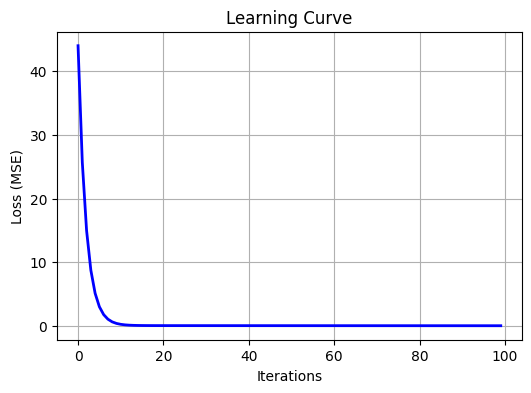

In [4]:
plt.figure(figsize=(6,4))

plt.plot(losses, color="blue", linewidth=2)

plt.title("Learning Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss (MSE)")
plt.grid(True)

plt.show()

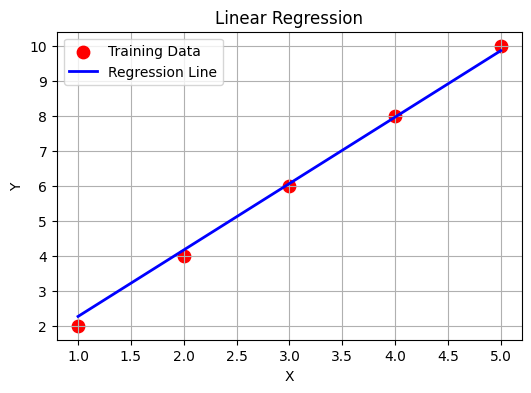

In [5]:
plt.figure(figsize=(6,4))

plt.scatter(X, Y, color="red", s=80, label="Training Data")
plt.plot(X, w * X + b, color="blue", linewidth=2, label="Regression Line")

plt.title("Linear Regression")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)

plt.show()

In [10]:
plt.savefig('linear_regression_plot.png')

<Figure size 640x480 with 0 Axes>

In [7]:
## Result

The Linear Regression model was successfully implemented using Gradient Descent. The Mean Squared Error (MSE) decreased over iterations, demonstrating convergence. The final regression line accurately fit the training data.

SyntaxError: invalid syntax (1874873372.py, line 3)

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic data
np.random.seed(42)

true_mean = 5
true_std = 2

data = np.random.normal(loc=true_mean,
                        scale=true_std,
                        size=1000)

# Maximum Likelihood Estimates
estimated_mean = np.mean(data)
estimated_variance = np.var(data)

print("Actual Mean :", true_mean)
print("Estimated Mean :", round(estimated_mean,4))

print()

print("Actual Variance :", true_std**2)
print("Estimated Variance :", round(estimated_variance,4))

Actual Mean : 5
Estimated Mean : 5.0387

Actual Variance : 4
Estimated Variance : 3.8316


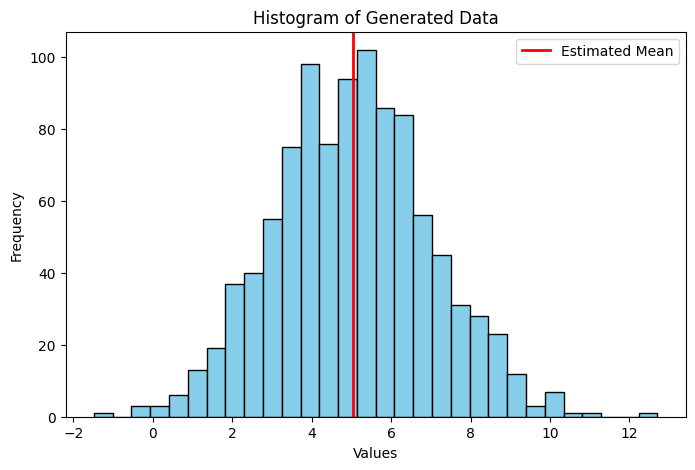

In [12]:
plt.figure(figsize=(8,5))

plt.hist(data,
         bins=30,
         color="skyblue",
         edgecolor="black")

plt.axvline(estimated_mean,
            color="red",
            linewidth=2,
            label="Estimated Mean")

plt.title("Histogram of Generated Data")
plt.xlabel("Values")
plt.ylabel("Frequency")

plt.legend()

plt.show()

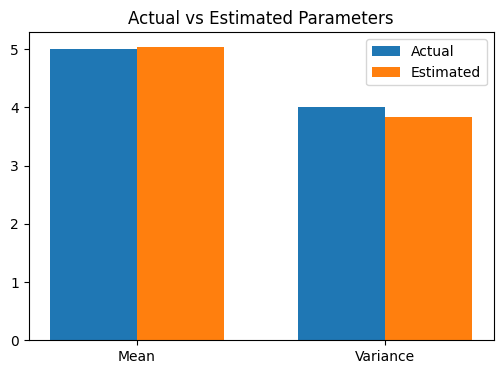

In [13]:
parameters = ["Mean", "Variance"]

actual = [true_mean, true_std**2]
estimated = [estimated_mean, estimated_variance]

x = np.arange(len(parameters))
width = 0.35

plt.figure(figsize=(6,4))

plt.bar(x-width/2, actual, width,
        label="Actual")

plt.bar(x+width/2, estimated, width,
        label="Estimated")

plt.xticks(x, parameters)

plt.title("Actual vs Estimated Parameters")

plt.legend()

plt.show()

# Experiment 3

## Aim

To build a Machine Learning Classification Model using the Iris dataset and evaluate its performance.

## Theory

A Machine Learning pipeline consists of several stages:

1. Data Collection
2. Data Preprocessing
3. Train-Test Split
4. Model Training
5. Prediction
6. Performance Evaluation

In this experiment, Logistic Regression is used as the classification algorithm. The model is trained using the Iris dataset and evaluated using Accuracy Score and Confusion Matrix.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [15]:
# Load Iris Dataset

iris = load_iris()

X = iris.data
y = iris.target

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (150, 4)
Target Shape: (150,)


In [16]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 120
Testing Samples: 30


In [17]:
model = LogisticRegression(max_iter=200)

model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


In [18]:
y_pred = model.predict(X_test)

print(y_pred)

[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [19]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


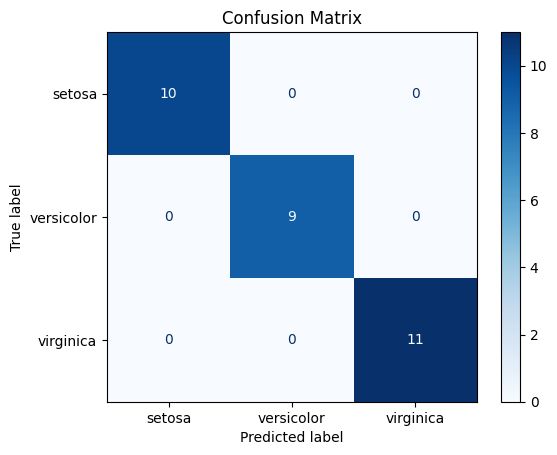

In [20]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [21]:
df = pd.DataFrame(
    X,
    columns=iris.feature_names
)

df["Species"] = y

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Species  
0        0  
1        0  
2        0  
3        0  
4        0  


# Experiment 4

## Aim

To implement a Neural Network with one hidden layer using the Iris dataset and analyze how it learns non-linear patterns.

## Theory

A Neural Network is a machine learning model inspired by the human brain. It consists of interconnected neurons organized into layers.

A simple Neural Network contains:

• Input Layer
• Hidden Layer
• Output Layer

The hidden layer learns complex and non-linear relationships between the input features and output classes.

In this experiment, we use an MLP (Multilayer Perceptron) with one hidden layer containing 5 neurons.

In [22]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [23]:
iris = load_iris()

X = iris.data
y = iris.target

print("Dataset Loaded Successfully")
print("Shape:", X.shape)

Dataset Loaded Successfully
Shape: (150, 4)


In [24]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:",len(X_train))
print("Testing Samples:",len(X_test))

Training Samples: 120
Testing Samples: 30


In [25]:
model = MLPClassifier(

    hidden_layer_sizes=(5,),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42
)

model.fit(X_train,y_train)

print("Neural Network Trained Successfully")

Neural Network Trained Successfully


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [26]:
y_pred = model.predict(X_test)

print(y_pred)

[2 0 2 2 2 0 1 2 2 1 2 0 0 0 0 2 2 1 2 2 0 2 0 2 2 2 2 2 0 0]


In [27]:
accuracy = accuracy_score(y_test,y_pred)

print("Accuracy =",accuracy)

Accuracy = 0.8


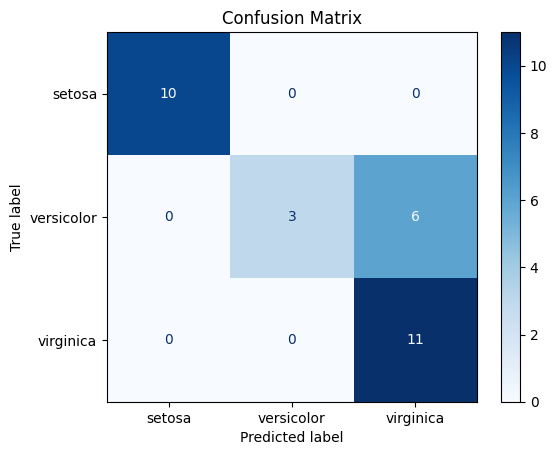

In [28]:
cm = confusion_matrix(y_test,y_pred)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,
    display_labels=iris.target_names

)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

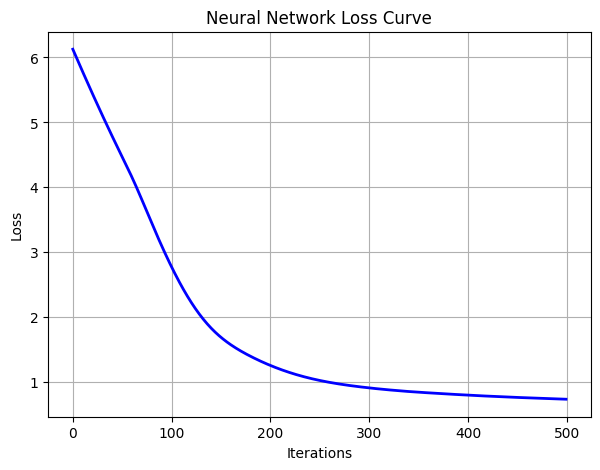

In [29]:
plt.figure(figsize=(7,5))

plt.plot(model.loss_curve_,
         color="blue",
         linewidth=2)

plt.title("Neural Network Loss Curve")

plt.xlabel("Iterations")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

In [30]:
for i in range(10):

    print("Actual:",y_test[i],
          "Predicted:",y_pred[i])

Actual: 1 Predicted: 2
Actual: 0 Predicted: 0
Actual: 2 Predicted: 2
Actual: 1 Predicted: 2
Actual: 1 Predicted: 2
Actual: 0 Predicted: 0
Actual: 1 Predicted: 1
Actual: 2 Predicted: 2
Actual: 1 Predicted: 2
Actual: 1 Predicted: 1
